In [1]:
# --- cell 0: put the kernel at the repository root (clone first on Colab) ---
# Colab: fetch a fresh clone every run. A tab opened before a push silently
# keeps the old tree on "Save a copy in GitHub", so always start a new session.
# Local: the kernel usually starts in notebooks/; walk up to the checkout.
import os, shutil, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/parsaileslamlou/Insole.git"
IN_COLAB = "google.colab" in sys.modules

def sh(*cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode:
        raise SystemExit(f"FAILED: {' '.join(cmd)}\n{r.stdout}{r.stderr}")
    return r.stdout.strip()

if IN_COLAB:
    REPO_DIR = "/content/Insole"
    os.chdir("/content")                          # step out before deleting
    shutil.rmtree(REPO_DIR, ignore_errors=True)   # a stale clone never sees a push
    sh("git", "clone", "-q", REPO_URL, REPO_DIR)
    os.chdir(REPO_DIR)
    sh(sys.executable, "-m", "pip", "install", "-q", "-e", ".")
else:
    here = Path.cwd()
    REPO_DIR = str(next(p for p in (here, *here.parents)
                        if (p / "insole" / "detector.py").exists()))
    os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)                  # what makes `import insole` work

# data/sim/sim_*.csv are gitignored, so only the .txt streams arrive in a clone.
# This regenerates them from the committed streams -- same data, no reseeding.
for stem in ["sim_walk", "sim_fast", "sim_shuffle", "sim_dropout", "sim_stand"]:
    sh(sys.executable, "-m", "insole.read_serial",
       f"data/sim/{stem}.txt", f"data/sim/{stem}.csv")

print(sh("git", "log", "--oneline", "-1"))
print("cwd:               ", os.getcwd())
print("insole/detector.py:", os.path.exists("insole/detector.py"))
print("data/sim csvs:     ", sorted(f for f in os.listdir("data/sim") if f.endswith(".csv")))


a6fc629 docs: regenerate every number the second session moved
cwd:                C:\Users\kingp\source\repos\Insole
insole/detector.py: True
data/sim csvs:      ['demo_faulty.csv', 'demo_walk.csv', 'features_sessions.csv', 'sim_dropout.csv', 'sim_fast.csv', 'sim_fast_00.csv', 'sim_fast_01.csv', 'sim_fast_02.csv', 'sim_fast_03.csv', 'sim_shuffle.csv', 'sim_shuffle_00.csv', 'sim_shuffle_01.csv', 'sim_shuffle_02.csv', 'sim_shuffle_03.csv', 'sim_stand.csv', 'sim_walk.csv', 'sim_walk_00.csv', 'sim_walk_01.csv', 'sim_walk_02.csv', 'sim_walk_03.csv']


In [2]:
import pandas as pd

# The five simulated streams are produced by:
#   python -m insole.gait_gen     -> the five sim_*.txt (committed under data/sim/)
#   python -m insole.read_serial data/sim/sim_walk.txt data/sim/sim_walk.csv   (and so on)
df = pd.read_csv("data/sim/sim_walk.csv")


In [3]:
def load_sessions(paths): # list of file paths
  frames = []
  for p in paths:
        temp_df = pd.read_csv(p)
        temp_df = temp_df.reset_index(drop=True) # Ensure a simple RangeIndex
        frames.append(temp_df)
  return pd.concat(frames, keys=paths)

In [4]:
combined = load_sessions(["data/sim/sim_walk.csv"])
combined.shape
combined.index[:3]


MultiIndex([('data/sim/sim_walk.csv', 0),
            ('data/sim/sim_walk.csv', 1),
            ('data/sim/sim_walk.csv', 2)],
           )

In [5]:
def clean(df):
  before = len(df)
  sensors = df[["s0","s1","s2","s3","s4","s5"]]
  ok = ((sensors >= 0) & (sensors <= 4095)).all(axis=1)
  print("dropped:", before - len(df[ok]), "of", before)
  return df[ok]



In [6]:
cleaned = clean(combined)
print(cleaned.shape)

dropped: 0 of 6000
(6000, 8)


In [7]:
import numpy as np
values = cleaned[["s0","s1","s2","s3","s4","s5"]].to_numpy()
print(values.shape)
first = values[0:100, :]
print(first.shape)

(6000, 6)
(100, 6)


In [8]:
def window(values, length, stride):
  n = (len(values) - length) // stride + 1
  out = []
  for k in range(n):
        start = k * stride
        out.append(values[start : start + length, :])
  return np.stack(out)

w = window(values, 100, 50)
print(w.shape)

(119, 100, 6)


In [9]:
sensors = cleaned[["s0","s1","s2","s3","s4","s5"]]

summary = pd.DataFrame({
    "mean": sensors.mean(),
    "peak": sensors.max(),
    "active_frac": (sensors > 100).mean(),
})

print(summary)

          mean  peak  active_frac
s0  617.256000  3245       0.2900
s1  274.197500  1446       0.2895
s2  420.366833  2660       0.2400
s3  452.671500  2847       0.2400
s4  329.011333  2252       0.2200
s5  202.234833  1851       0.1600


In [10]:
toy = cleaned.head(20)
toy.to_csv("toy.csv", index=False)

In [11]:
t = load_sessions(["toy.csv"])
t = clean(t)
tv = t[["s0","s1","s2","s3","s4","s5"]].to_numpy()
tw = window(tv, 5, 5)
print(tw.shape)

dropped: 0 of 20
(4, 5, 6)


In [12]:
import numpy as np
import matplotlib.pyplot as plt

from insole.detector import SENSOR_COLS


def plot_session(df, flagged_times=None, title="Session"):
    t_sec = df["ts_us"] / 1e6
    fig, axes = plt.subplots(6, 1, sharex=True, sharey=True, figsize=(11, 9))
    for i, col in enumerate(SENSOR_COLS):
        ax = axes[i]
        ax.plot(t_sec, df[col], linewidth=0.8)
        ax.set_ylabel(col, rotation=0, labelpad=18, va="center")
        ax.grid(alpha=0.3)
        if flagged_times is not None:
            for ft in flagged_times:
                ax.axvline(ft, color="red", linewidth=1.0, alpha=0.7)
    axes[0].set_title(title)
    axes[-1].set_xlabel("time (s)")
    axes[-1].set_ylim(0, 4095)
    fig.tight_layout()
    return fig, axes


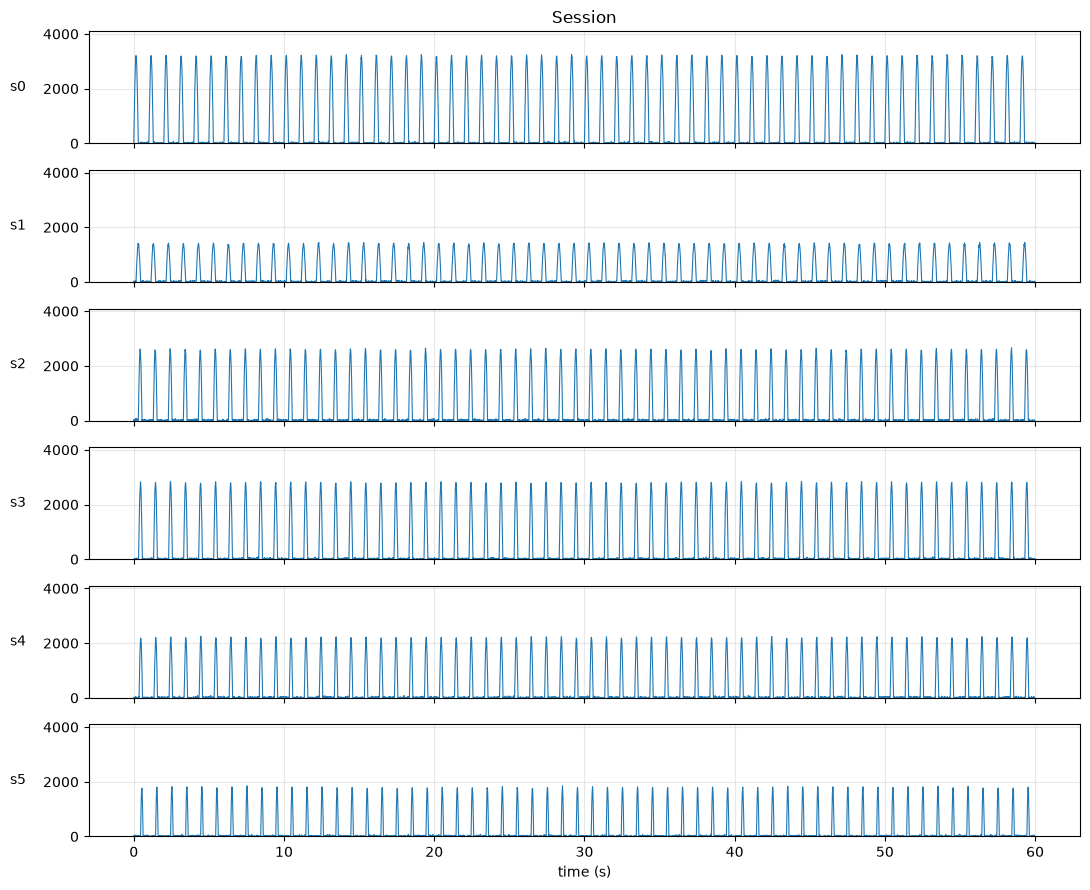

In [13]:
fig, axes = plot_session(cleaned)

In [14]:
# find_stances used to be defined here. It now lives in detector.py so that
# test_stances.py can import the same definition -- a test cannot import a
# notebook cell, and a second copy would drift until the test passed against
# a stale detector.
#
# Constants are re-exported for the plotting cell below. All are RETUNE.
from insole.detector import (
    find_stances, merge_close, stance_report,
    T_ON, T_OFF, MIN_DURATION, MAX_DURATION, GAP_MERGE,
)

print(f"T_ON={T_ON} T_OFF={T_OFF} MIN_DURATION={MIN_DURATION} "
      f"MAX_DURATION={MAX_DURATION} GAP_MERGE={GAP_MERGE}")


T_ON=1200 T_OFF=450 MIN_DURATION=15 MAX_DURATION=200 GAP_MERGE=12


In [15]:
def plot_stances(t_sec, total, stances, xlim=None, title="Detected stances"):
    fig, ax = plt.subplots(1, 1, figsize=(11, 4))
    for (a, b) in stances:
        ax.axvspan(t_sec[a], t_sec[b], color="#1D9E75", alpha=0.18, linewidth=0)
    ax.plot(t_sec, total, linewidth=0.9, color="#378ADD")
    ax.axhline(T_ON, color="#888780", linestyle="--", linewidth=0.8)
    ax.axhline(T_OFF, color="#888780", linestyle=":", linewidth=0.8)
    ax.text(t_sec[0], T_ON, " T_ON", va="bottom", fontsize=8, color="#666")
    ax.text(t_sec[0], T_OFF, " T_OFF", va="bottom", fontsize=8, color="#666")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("total force (ADC counts)")
    ax.set_title(f"{title} - {len(stances)} stances")
    ax.grid(alpha=0.3)
    if xlim is not None:
        ax.set_xlim(*xlim)
    fig.tight_layout()
    return fig, ax

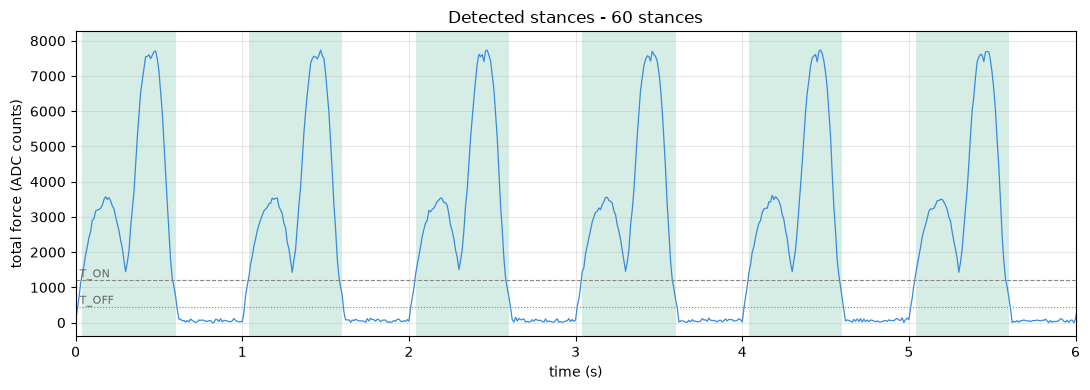

In [16]:
t_sec = (cleaned["ts_us"] / 1e6).to_numpy()
total = values.sum(axis=1)
stances = merge_close(find_stances(total))
fig, ax = plot_stances(t_sec, total, stances, xlim=(0, 6))


In [17]:
def overlap(x, y):
    return max(0, min(x[1], y[1]) - max(x[0], y[0]) + 1)

def match_stances(detected, truth, min_overlap=0.5):
    claimed = set()
    tp = 0
    for d in detected:
        best, best_ov = None, 0
        for j, t in enumerate(truth):
            if j in claimed:
                continue
            ov = overlap(d, t)
            if ov > best_ov:
                best, best_ov = j, ov
        if best is not None and best_ov >= min_overlap * (truth[best][1] - truth[best][0] + 1):
            claimed.add(best)
            tp += 1
    fp = len(detected) - tp
    fn = len(truth) - tp
    return tp, fp, fn

def precision_recall(tp, fp, fn):
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    return p, r


## Segmentation scorecard

Precision and recall over all five simulated streams, next to the boundary
errors that P/R cannot see.

**Read the last three columns, not the first six.** On simulated streams the
truth intervals are derived from the same constants that generated the data,
so a perfect P/R validates the *matching* code, not the detector. The mean
start / end / duration errors are the honest columns: they are what the
counts are structurally blind to, and a detector that finds every stance
while clipping 15% off each contact time still scores 1.000.

The real test is hardware data.


In [18]:
from insole.gait_gen import SHUFFLE_CYCLE_S, true_stances

# (csv, gait_gen mode for truth, cycle_s for truth)
STREAMS = [
    ("data/sim/sim_walk.csv",    "walk",     1.0),
    ("data/sim/sim_fast.csv",    "walk",     0.6),
    ("data/sim/sim_shuffle.csv", "shuffle",  SHUFFLE_CYCLE_S),
    ("data/sim/sim_dropout.csv", "walk",     1.0),
    ("data/sim/sim_stand.csv",   "standing", 1.0),
]

rows = []
for path, mode, cycle_s in STREAMS:
    # Read directly rather than via load_sessions: that helper overwrites
    # ts_us with df.index * 10000, which would launder any real jitter.
    stream = pd.read_csv(path)
    total_force = stream[SENSOR_COLS].sum(axis=1).to_numpy()

    detected = merge_close(find_stances(total_force))
    truth = true_stances(60, mode=mode, cycle_s=cycle_s)

    tp, fp, fn = match_stances(detected, truth, min_overlap=0.5)
    p, r = precision_recall(tp, fp, fn)
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    if not detected and not truth:
        # Correctly finding nothing in a stream that contains nothing. P/R are
        # undefined here, not zero; precision_recall returns 0.0 for the empty
        # case, which would read as a failed row for the one stream that is
        # exactly right.
        p = r = f1 = float("nan")
    rep = stance_report(detected, truth)

    rows.append({
        "stream": path.replace("data/sim/sim_", "").replace(".csv", ""),
        "detected": len(detected),
        "truth": len(truth),
        "TP": tp, "FP": fp, "FN": fn,
        "P": round(p, 3), "R": round(r, 3), "F1": round(f1, 3),
        "start_off_fr": round(rep["mean_start_offset"], 1),
        "end_off_fr": round(rep["mean_end_offset"], 1),
        "dur_err_fr": round(rep["mean_duration_error"], 1),
    })

scorecard = pd.DataFrame(rows)
print(scorecard.to_string(index=False))


 stream  detected  truth  TP  FP  FN   P   R  F1  start_off_fr  end_off_fr  dur_err_fr
   walk        60     60  60   0   0 1.0 1.0 1.0           4.0        -0.9        -5.0
   fast       100    100 100   0   0 1.0 1.0 1.0           2.9         0.0        -2.9
shuffle       120    120 120   0   0 1.0 1.0 1.0           5.0        -1.0        -6.0
dropout        60     60  60   0   0 1.0 1.0 1.0          10.9        -1.0       -11.9
  stand         0      0   0   0   0 NaN NaN NaN           NaN         NaN         NaN


In [19]:
# Both of these were previously redeclared here, in heatmap.py and in
# detector.py. One definition now, in detector.py.
from insole.detector import SENSOR_COLS, SENSOR_COORDS

print(SENSOR_COORDS)


{'s0': (0.12043795620437957, 0.1854014598540146), 's1': (0.1854014598540146, 0.1854014598540146), 's2': (0.2781021897810219, 0.5562043795620438), 's3': (0.29671532846715326, 0.6766423357664234), 's4': (0.0927007299270073, 0.7416058394160584), 's5': (0.0927007299270073, 0.927007299270073)}


In [20]:
# These six were defined here. They now live in features.py so scripts and
# tests import the same definitions this notebook uses -- a test cannot import
# a notebook cell, and a second copy drifts until the test passes against a
# stale extractor. Same reason find_stances moved into detector.py.
from insole.features import (
    frame_dt, stance_features,
    cop_frame, cop_trajectory, cop_features,
    extract_features,
)

In [21]:
feat = extract_features(cleaned, stances, "walk")
# NOT "readings.csv": that is a raw-capture filename, and writing features
# over it silently replaced the raw stream on any re-run.
feat.to_csv("features_walk.csv", index=False)
print(feat.shape)


(60, 10)


In [22]:
fast_raw = load_sessions(["data/sim/sim_fast.csv"])
fast_clean = clean(fast_raw)
fast_total = fast_clean[SENSOR_COLS].sum(axis=1).to_numpy()
fast_stances = merge_close(find_stances(fast_total))
feat_fast = extract_features(fast_clean, fast_stances, "fast")
print(feat_fast.shape)


dropped: 0 of 6000


(100, 10)


In [23]:
all_feat = pd.concat([feat, feat_fast], ignore_index=True)

In [24]:
all_feat.shape
all_feat["label"].value_counts()

label
fast    100
walk     60
Name: count, dtype: int64

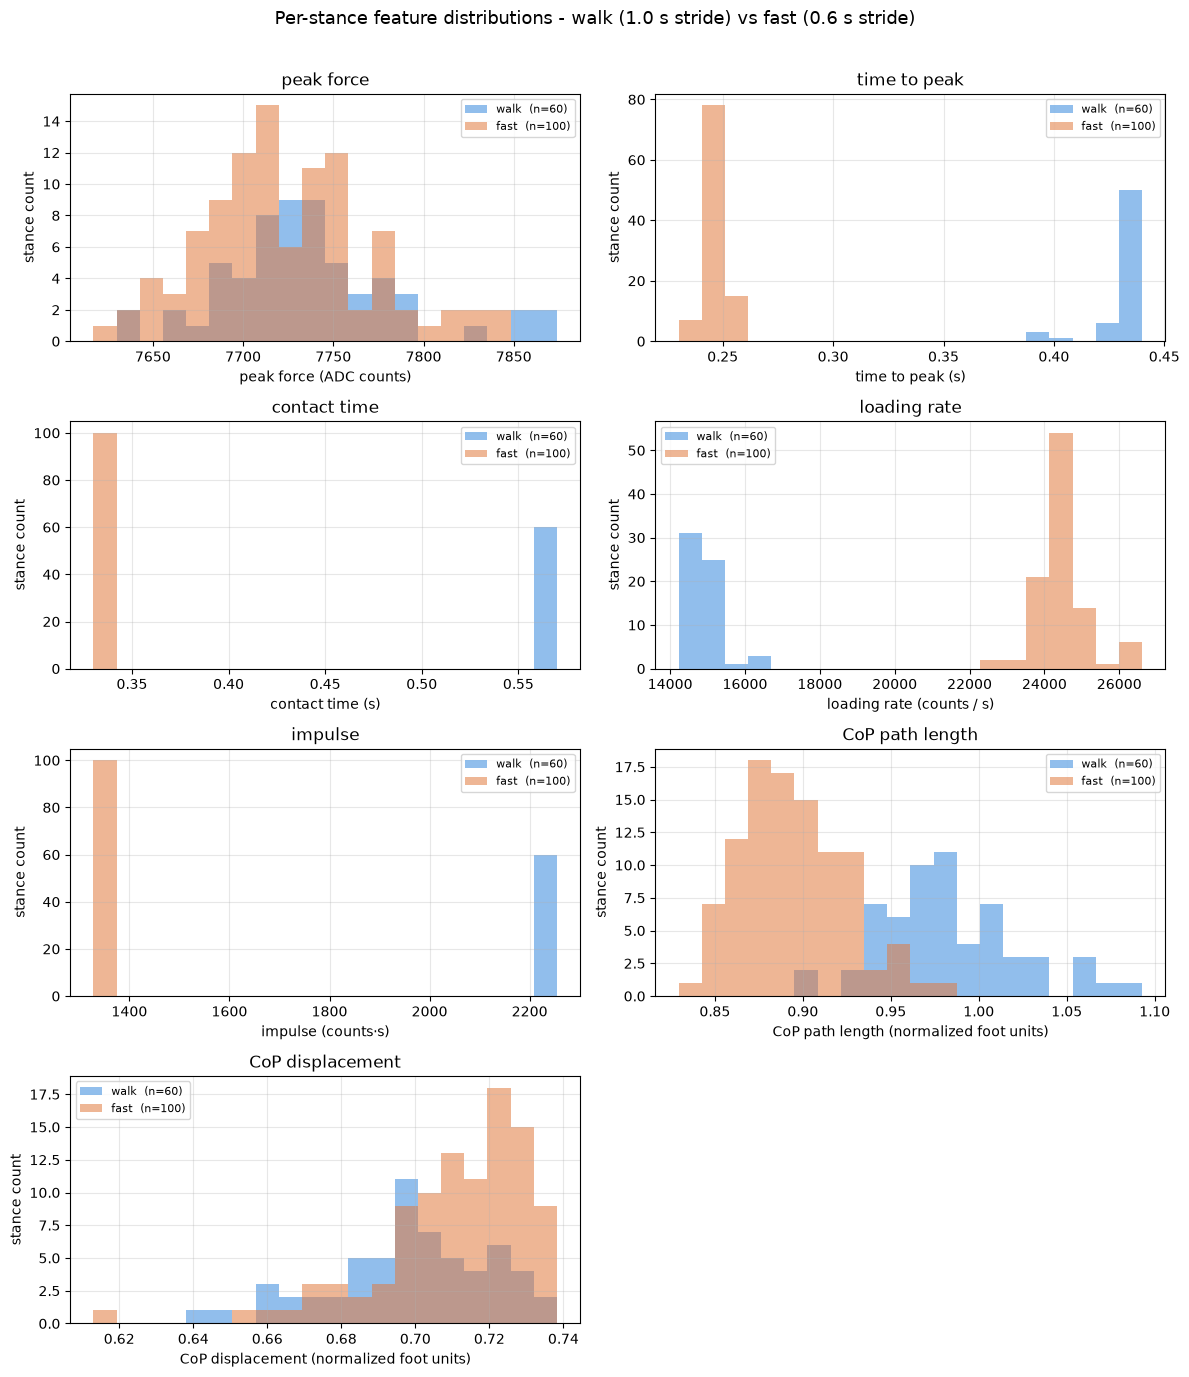

In [25]:
import matplotlib.pyplot as plt
import numpy as np

FEATURES = [
    ("peak_counts",      "peak force",      "ADC counts"),
    ("time_to_peak_s",   "time to peak",    "s"),
    ("contact_time_s",   "contact time",    "s"),
    ("loading_rate_cps", "loading rate",    "counts / s"),
    ("impulse_counts_s", "impulse",         "counts·s"),
    ("cop_path_len",     "CoP path length", "normalized foot units"),
    ("cop_displacement", "CoP displacement","normalized foot units"),
]

COLORS = {"walk": "#378ADD", "fast": "#E07A3F"}

fig, axes = plt.subplots(4, 2, figsize=(12, 14))

for ax, (col, nice_name, unit) in zip(axes.flat, FEATURES):
    series = all_feat[col].dropna()
    edges = np.histogram_bin_edges(series, bins=20)

    for label in ["walk", "fast"]:
        subset = all_feat.loc[all_feat["label"] == label, col].dropna()
        ax.hist(subset, bins=edges, alpha=0.55,
                color=COLORS[label], label=f"{label}  (n={len(subset)})")

    ax.set_title(nice_name)
    ax.set_xlabel(f"{nice_name} ({unit})")
    ax.set_ylabel("stance count")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes.flat[-1].axis("off")
fig.suptitle("Per-stance feature distributions - walk (1.0 s stride) vs fast (0.6 s stride)",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])

In [26]:
from insole import heatmap as H
out, dt = H.animate(cleaned, stances[0], cop_fn=cop_frame,
                    vmax=float(cleaned.iloc[stances[0][0]:stances[0][1]][SENSOR_COLS].to_numpy().max()))

In [27]:
# Feature subset for the models. CoP only.
#
# The other five (peak_counts, time_to_peak_s, contact_time_s,
# loading_rate_cps, impulse_counts_s) are cadence one division removed, and
# the classes are defined by changing stride period in make_sessions.py. On
# the full seven every model scores 1.000 and the comparison measures the
# label-generating process rather than the models.
#
# Named COP_FEATURES, not FEATURES: the plotting cell above already binds
# FEATURES to a list of (column, label, unit) tuples, and reusing the name
# breaks that cell on re-run. bakeoff.py calls this same list FEATURES.
COP_FEATURES = ["cop_path_len", "cop_displacement"]